<h1 style="text-align:center;">Reinforcement Learning : Deterministic Maze</h1>

Problem setup : Finding the optimal path on a determinist grid (no exploration problem)

## Sommaire :

* [**1.Generation aleatory grid**](#0)


* [**2.Naive approach :**](#1)

* [**3.Breadth-First Search :**](#2)

* [**4.$A^{*}$ :**](#3)

In [45]:
# Modules 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from collections import deque
import heapq

<a id='0'></a>
# 1. Generate aleatory grid :

In [29]:
def generate_aleatory_grid(n, complexity=0.2, seed=None):
    """
    Grille n×n avec 1 = mur, 0 = passage.
    Chemin aléatoire depuis colonne 0 jusqu'à colonne n-1.
    Complexité pour créer des fausses pistes

    Mouvements possibles à chaque pas :
      - droite : (row, col+1)
      - haut   : (row-1, col)  (même colonne)
      - bas    : (row+1, col)  (même colonne)

    """
    if seed is not None:
        np.random.seed(seed)

    grid = np.ones((n, n), dtype=int)

    # départ aléatoire colonne 0
    row = np.random.randint(0, n)
    col = 0
    grid[row, col] = 0
    col = 1
    grid[row, col] = 0

    # chemin jusqu'à la dernière colonne
    while col < n - 1:

        moves = ["R"]  # droite toujours possible tant qu'on n'est pas à la fin
        if row > 0:
            moves.append("U")  # up
        if row < n - 1:
            moves.append("D")  # down

        move = np.random.choice(moves)

        if move == "R":
            col += 1
        elif move == "U":
            row -= 1
        else:  # "D"
            row += 1

        grid[row, col] = 0

    # Rajout de la condition de complexité
    while (n**2 - np.sum(grid))/n**2 < complexity :
        col = np.random.randint(1, n-1)
        row = np.random.randint(1, n-1)
        grid[row, col] = 0

    return grid

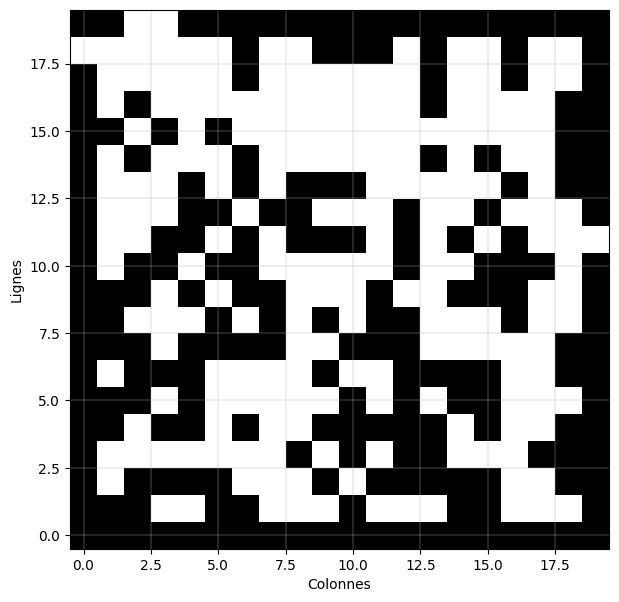

In [30]:
# --------- test + plot ----------
n = 20
grid = generate_aleatory_grid(n, complexity=0.5)

plt.figure(figsize=(7, 7))
plt.imshow(grid, cmap="gray_r", origin="lower")
plt.xlabel("Colonnes")
plt.ylabel("Lignes")
plt.grid(True, linewidth=0.3)
plt.show()

<a id='1'></a>
# 2. Naive approach :

In [31]:
def chemin_de_sortie_naif(grid):
    '''
    Trouver un chemin de sortie Naîf : 
    On prend toute les directions au hasard jusqu'à trouver la sortie
    '''

    # Recherche du point de départ
    start = np.where(grid[:, 0] == 0)[0][0]

    # Taille grille
    n = len(grid[0])

    point = [start, 0]   # Point initial
    pointeur = point[1]

    list_pointeur = []   # Enregistre les positions du pointeurs : pour évaluer la complexité
    list_pointeur.append(point.copy())

    while pointeur < n - 1:

        # Définition de Omega : ensemble des moves possibles
        omega = []    # Up, down, left, right

        # U : (i+1, j)
        if point[0] < n - 1 and grid[point[0] + 1, point[1]] == 0:
            omega.append('U')

        # D : (i-1, j)
        if point[0] > 0 and grid[point[0] - 1, point[1]] == 0:
            omega.append('D')

        # L : (i, j-1)
        if point[1] > 0 and grid[point[0], point[1] - 1] == 0:
            omega.append('L')

        # R : (i, j+1)
        if point[1] < n - 1 and grid[point[0], point[1] + 1] == 0:
            omega.append('R')

        # Si bloqué (cul-de-sac)
        if len(omega) == 0:
            break

        move = np.random.choice(omega)

        if move == 'U':
            point[0] += 1
        if move == 'D':
            point[0] += -1
        if move == 'L':
            point[1] += -1
        if move == 'R':
            point[1] += 1

        list_pointeur.append(point.copy())  # Copie sinon mes points changent à chaque fois
        pointeur = point[1]

    return len(list_pointeur), list_pointeur

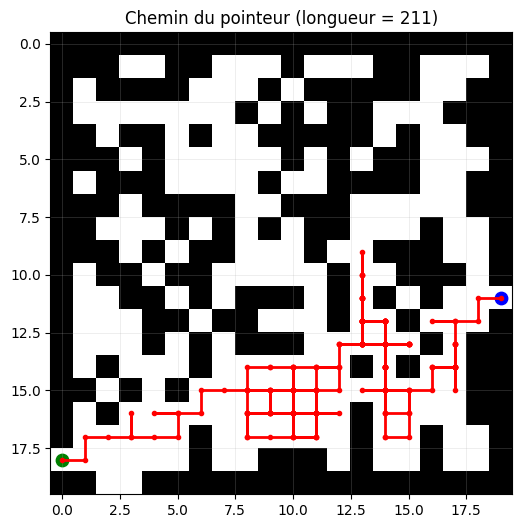

In [32]:
# Run algo
length, path = chemin_de_sortie_naif(grid)

# Convert path -> array
path = np.array(path)  # shape (m,2)

# Plot grid
plt.figure(figsize=(6, 6))
plt.imshow(grid, cmap="gray_r", origin="upper")

# Plot chemin en rouge
plt.plot(path[:, 1], path[:, 0], color="red", linewidth=2, marker="o", markersize=3)

# Start / End
plt.scatter(path[0, 1], path[0, 0], color="green", s=80)
plt.scatter(path[-1, 1], path[-1, 0], color="blue", s=80)

plt.grid(True, linewidth=0.5, alpha=0.3)
plt.title(f"Chemin du pointeur (longueur = {length})")
plt.show()

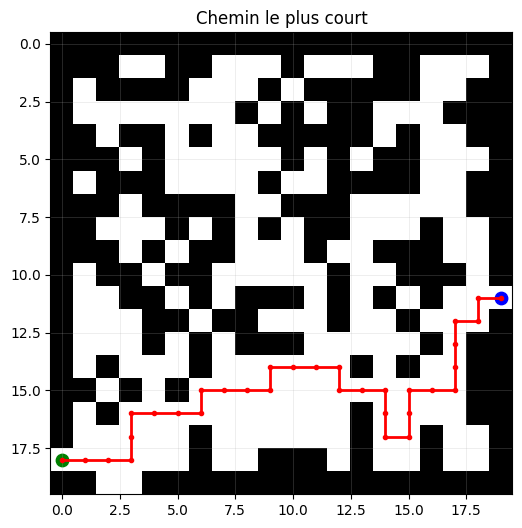

In [33]:
## Chemin "optimal" 
# On annule tous les points entre chaques points deux fois visité

length, path = chemin_de_sortie_naif(grid)

# Run algo
k = 0
while k < len(path):
    found = False
    for i in range(k):
        if path[k] == path[i]:
            # on supprime la boucle : i+1 ... k inclus
            path = path[:i+1] + path[k+1:]
            k = i + 1          # on repart juste après i
            found = True
            break              # on sort du for
    if not found:
        k += 1


# Convert path -> array
path = np.array(path)  # shape (m,2)

# Plot grid
plt.figure(figsize=(6, 6))
plt.imshow(grid, cmap="gray_r", origin="upper")

# Plot chemin en rouge
plt.plot(path[:, 1], path[:, 0], color="red", linewidth=2, marker="o", markersize=3)

# Start / End
plt.scatter(path[0, 1], path[0, 0], color="green", s=80)
plt.scatter(path[-1, 1], path[-1, 0], color="blue", s=80)

plt.grid(True, linewidth=0.5, alpha=0.3)
plt.title(f"Chemin le plus court")
plt.show()

<a id='2'></a>

# 3. Breadth-First Search (BFS) / $\sim$  Dijkstra

**Objectif :** trouver un plus court chemin entre `start` et `end` dans une grille `grid ∈ {0,1}^{n×n}`  
(0 = libre, 1 = mur)

**Hypothèse :** chaque déplacement (haut/bas/gauche/droite) a un coût = 1  
⇒ on cherche le chemin avec le **minimum de pas**.

---

## Principe

BFS explore la grille **par couches de distance** :
- couche 0 : `start`
- couche 1 : cases atteignables en 1 pas
- couche 2 : cases atteignables en 2 pas
- ...

Ainsi, **la première fois** qu’on atteint `end`, on obtient un chemin **optimal** (en nombre de pas).

---

## Structures utilisées

- `Q` : file FIFO (queue)
- `visited` : cases déjà visitées
- `parent` : dictionnaire de reconstruction du chemin
- `dist` : distance

---

## Pseudo-code

```text
BFS(grid, start, end):

    Q = file FIFO
    Q.push(start)

    visited = {start}
    parent[start] = NULL
    dist[start] = 0

    while Q not empty:

        x = Q.pop_left()

        if x == end:
            break

        for each neighbor y of x (up/down/left/right):
            if y is inside grid AND grid[y] == 0 AND y not in visited:
                visited.add(y)
                parent[y] = x
                dist[y] = dist[x] + 1
                Q.push(y)

    if end not in visited:
        return "pas de chemin"

    # reconstruction
    path = []
    cur = end
    while cur != NULL:
        path.append(cur)
        cur = parent[cur]
    reverse(path)

    return path, dist[end]

In [41]:
def chemin_de_sortie_BFS(grid):
    '''
    Trouver un chemin de sortie "optimal" avec BFS (Breadth-First Search)

    Principe :
    - On part du point de départ (premier 0 sur la colonne 0)
    - On explore toutes les cases accessibles par couches (distance 0, 1, 2, ...)
    - Dès qu'on atteint une case de la dernière colonne, on a un plus court chemin
    - On reconstruit le chemin grâce au dictionnaire parent
    - On renvoie aussi les distances BFS pour toutes les cases atteintes

    Entrée :
    - grid : numpy array (n,n) avec 0 = passage libre, 1 = mur

    Sortie :
    - (length, path, list_dist)
      * length    : longueur du chemin (nombre de points)
      * path      : liste des points [[i0,j0], ..., [i_end, j_end]]
      * list_dist : liste de triplets [[i, j, d], ...] pour toutes les cases visitées
                   où d = distance minimale depuis start
    '''

    # Taille grille
    n = grid.shape[0]

    # Recherche du point de départ (premier 0 sur la colonne 0)
    start_i = np.where(grid[:, 0] == 0)[0][0]
    start = (int(start_i), 0)
    i, j = start  # Coordonnées start

    # Définition de la sortie : premier 0 sur la dernière colonne
    end_i = np.where(grid[:, n - 1] == 0)[0][0]
    end = (int(end_i), n - 1)
    i_end, j_end = end  # Coordonnées end

    # parent = dictionnaire pour reconstruire le chemin
    parent = {start: None}

    # dist = dictionnaire distance depuis start
    dist = {start: 0}

    # Dictionnaire Bool visité ou pas ?
    visited_bool = {(x, y): 0 for x in range(n) for y in range(n)}
    visited_bool[start] = 1

    # File BFS (queue)
    queue = deque([start])

    # Itération BFS
    while len(queue) > 0:

        # On prend la prochaine case à explorer (FIFO)
        (i, j) = queue.popleft()

        # Test est ce que on arrive à la fin ?
        if i == i_end and j == j_end:
            break

        # --- Voisins (4 directions) en gardant ta logique ---
        # Test en face : abscisse -> abscisse + 1
        if j < n - 1:
            if grid[i, j + 1] == 0 and visited_bool[(i, j + 1)] == 0:
                parent[(i, j + 1)] = (i, j)
                dist[(i, j + 1)] = dist[(i, j)] + 1
                visited_bool[(i, j + 1)] = 1
                queue.append((i, j + 1))

        # Test en arrière : abscisse -> abscisse - 1
        if j > 0:
            if grid[i, j - 1] == 0 and visited_bool[(i, j - 1)] == 0:
                parent[(i, j - 1)] = (i, j)
                dist[(i, j - 1)] = dist[(i, j)] + 1
                visited_bool[(i, j - 1)] = 1
                queue.append((i, j - 1))

        # Test en haut : ordonné -> ordonné + 1
        if i < n - 1:
            if grid[i + 1, j] == 0 and visited_bool[(i + 1, j)] == 0:
                parent[(i + 1, j)] = (i, j)
                dist[(i + 1, j)] = dist[(i, j)] + 1
                visited_bool[(i + 1, j)] = 1
                queue.append((i + 1, j))

        # Test en bas : ordonné -> ordonné - 1
        if i > 0:
            if grid[i - 1, j] == 0 and visited_bool[(i - 1, j)] == 0:
                parent[(i - 1, j)] = (i, j)
                dist[(i - 1, j)] = dist[(i, j)] + 1
                visited_bool[(i - 1, j)] = 1
                queue.append((i - 1, j))

    # -----------------------------
    # Reconstruction du chemin
    # -----------------------------
    path = []
    if end in parent:  # end atteint
        cur = end
        while cur is not None:
            path.append([cur[0], cur[1]])  
            cur = parent[cur]
        path = path[::-1]  # on inverse car on a reconstruit à l'envers

    # Liste des distances pour toutes les cases atteintes
    list_dist = [[p[0], p[1], d] for p, d in dist.items()]

    return len(path), path, list_dist

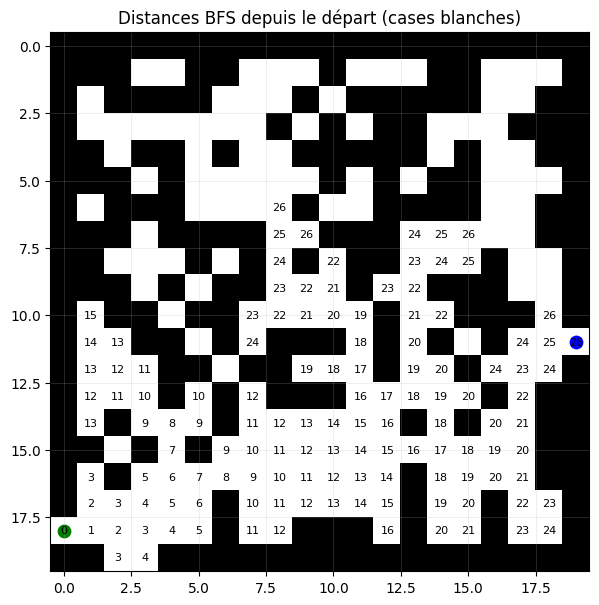

In [42]:
# -------------------------
# Distances BFS sur toute la grille
# -------------------------
length, path, list_dist = chemin_de_sortie_BFS(grid)

n = grid.shape[0]

# Matrice des distances (par défaut -1)
dist_mat = -np.ones((n, n), dtype=int)

# Remplir dist_mat avec list_dist = [[i,j,d], ...]
for i, j, d in list_dist:
    dist_mat[i, j] = d

# -------------------------
# Plot : grille + distances sur les cases blanches
# -------------------------
plt.figure(figsize=(7, 7))
plt.imshow(grid, cmap="gray_r", origin="upper")

for i in range(n):
    for j in range(n):
        if grid[i, j] == 0 and dist_mat[i, j] != -1:
            plt.text(j, i, str(dist_mat[i, j]),
                     ha="center", va="center",
                     fontsize=8, color="black")

# Start / End (optionnel)
plt.scatter(path[0][1], path[0][0], color="green", s=80)
plt.scatter(path[-1][1], path[-1][0], color="blue", s=80)

plt.grid(True, linewidth=0.5, alpha=0.3)
plt.title("Distances BFS depuis le départ (cases blanches)")
plt.show()


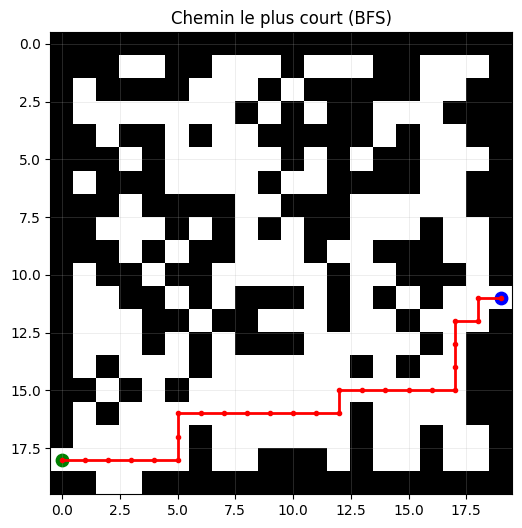

In [43]:
# -------------------------
# Chemin "optimal" (BFS)
# -------------------------
length, path, list_dist = chemin_de_sortie_BFS(grid)

# Convert path -> array
path = np.array(path)

# Plot grid
plt.figure(figsize=(6, 6))
plt.imshow(grid, cmap="gray_r", origin="upper")

# Plot chemin en rouge
plt.plot(path[:, 1], path[:, 0], color="red", linewidth=2, marker="o", markersize=3)

# Start / End
plt.scatter(path[0, 1], path[0, 0], color="green", s=80)
plt.scatter(path[-1, 1], path[-1, 0], color="blue", s=80)

plt.grid(True, linewidth=0.5, alpha=0.3)
plt.title("Chemin le plus court (BFS)")
plt.show()


<a id='3'></a>

# 4. A*

On considère une grille :

$$
grid \in \{0,1\}^{n\times n},
$$

avec :

- $0$ : case libre (passage)
- $1$ : mur

---

## Hypothèse : sortie connue

On suppose que l'on connaît la coordonnée de sortie :

$$
S = (S_i, S_j).
$$

---

## Idée de l'optimisation : heuristique

BFS explore "par couches" (distance 0, puis 1, puis 2, etc.).  
Pour explorer plus vite dans la direction de la sortie, on introduit une **heuristique** basée sur la distance de Manhattan.

---

## Distance de Manhattan

Pour une position courante :

$$
p = (p_i, p_j),
$$

la distance de Manhattan à la sortie $S$ est :

$$
D_{\text{Man}}(p,S)
=
|p_i - S_i|
+
|p_j - S_j|.
$$

---

## Fonction de coût A*

On définit :

- $g(p)$ : distance exacte depuis le départ jusqu'à $p$
- $h(p)$ : estimation de la distance restante jusqu'à la sortie (ici $h(p)=D_{\text{Man}}(p,S)$)

A* choisit d'explorer en priorité les positions minimisant :

$$
f(p) = g(p) + h(p).
$$

In [ ]:
def chemin_de_sortie_A_star(grid):
    '''
    Trouver un chemin de sortie "optimal" avec BFS optimisé (A*)

    Principe :
    - On explore en priorité les cases minimisant f = g + h
      * g = distance exacte depuis start
      * h = distance de Manhattan vers end
    - On reconstruit le chemin grâce au dictionnaire parent
    - On renvoie aussi les distances (g) pour toutes les cases atteintes

    Entrée :
    - grid : numpy array (n,n) avec 0 = passage libre, 1 = mur

    Sortie :
    - (length, path, list_dist)
    '''

    # Taille grille
    n = grid.shape[0]

    # Recherche du point de départ (premier 0 sur la colonne 0)
    start_i = np.where(grid[:, 0] == 0)[0][0]
    start = (int(start_i), 0)
    i, j = start  # Coordonnées start

    # Définition de la sortie : premier 0 sur la dernière colonne
    end_i = np.where(grid[:, n - 1] == 0)[0][0]
    end = (int(end_i), n - 1)
    i_end, j_end = end  # Coordonnées end

    # Fonction distance
    def manhattan(A, B):
        return abs(A[0] - B[0]) + abs(A[1] - B[1])

    # parent = dictionnaire pour reconstruire le chemin
    parent = {start: None}

    # dist = dictionnaire distance depuis start (g)
    dist = {start: 0}

    # Dictionnaire Bool visité ou pas ?
    visited_bool = {(x, y): 0 for x in range(n) for y in range(n)}

    # h pré-calculé 
    distances = {(x, y): manhattan((x, y), (i_end, j_end)) for x in range(n) for y in range(n)}

    # File A* (priority queue) : éléments = (f, g, (i,j))
    queue = []
    heapq.heappush(queue, (dist[start] + distances[start], dist[start], start))

    # Itération A*
    while len(queue) > 0:

        # On prend la prochaine case à explorer (min f = g + h)
        f_cur, g_cur, (i, j) = heapq.heappop(queue)

        # Si déjà traité, on saute (car on peut avoir des doublons dans le heap)
        if visited_bool[(i, j)] == 1:
            continue
        visited_bool[(i, j)] = 1

        # Test est ce que on arrive à la fin ?
        if i == i_end and j == j_end:
            break

        # --- Voisins (4 directions) en gardant ta logique ---
        # On rajoute une règle: tentative_g = g_cur + 1 ; si meilleur, update

        # Test en face : abscisse -> abscisse + 1
        if j < n - 1 and grid[i, j + 1] == 0:
            nxt = (i, j + 1)
            tentative_g = g_cur + 1
            if visited_bool[nxt] == 0 and (nxt not in dist or tentative_g < dist[nxt]):
                parent[nxt] = (i, j)
                dist[nxt] = tentative_g
                heapq.heappush(queue, (tentative_g + distances[nxt], tentative_g, nxt))

        # Test en arrière : abscisse -> abscisse - 1
        if j > 0 and grid[i, j - 1] == 0:
            nxt = (i, j - 1)
            tentative_g = g_cur + 1
            if visited_bool[nxt] == 0 and (nxt not in dist or tentative_g < dist[nxt]):
                parent[nxt] = (i, j)
                dist[nxt] = tentative_g
                heapq.heappush(queue, (tentative_g + distances[nxt], tentative_g, nxt))

        # Test en haut : ordonné -> ordonné + 1
        if i < n - 1 and grid[i + 1, j] == 0:
            nxt = (i + 1, j)
            tentative_g = g_cur + 1
            if visited_bool[nxt] == 0 and (nxt not in dist or tentative_g < dist[nxt]):
                parent[nxt] = (i, j)
                dist[nxt] = tentative_g
                heapq.heappush(queue, (tentative_g + distances[nxt], tentative_g, nxt))

        # Test en bas : ordonné -> ordonné - 1
        if i > 0 and grid[i - 1, j] == 0:
            nxt = (i - 1, j)
            tentative_g = g_cur + 1
            if visited_bool[nxt] == 0 and (nxt not in dist or tentative_g < dist[nxt]):
                parent[nxt] = (i, j)
                dist[nxt] = tentative_g
                heapq.heappush(queue, (tentative_g + distances[nxt], tentative_g, nxt))

    # -----------------------------
    # Reconstruction du chemin
    # -----------------------------
    path = []
    if end in parent:  # end atteint
        cur = end
        while cur is not None:
            path.append([cur[0], cur[1]])
            cur = parent[cur]
        path = path[::-1]

    # Liste des distances pour toutes les cases atteintes
    list_dist = [[p[0], p[1], d] for p, d in dist.items()]

    return len(path), path, list_dist

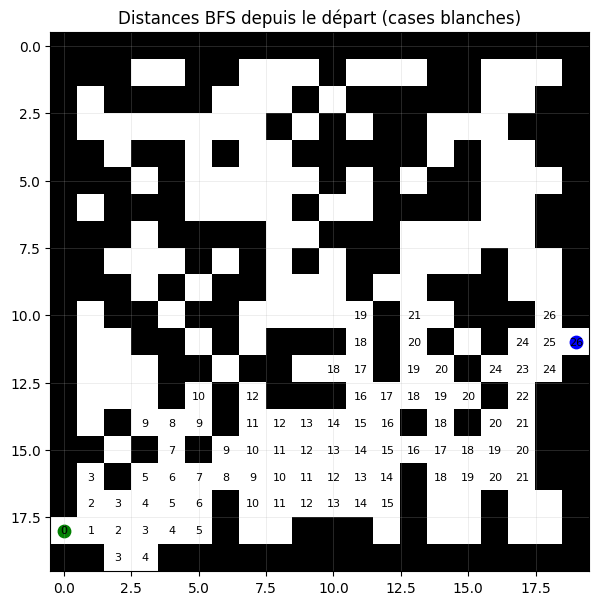

In [47]:
# -------------------------
# Distances BFS sur toute la grille
# -------------------------
length, path, list_dist = chemin_de_sortie_A_star(grid)

n = grid.shape[0]

# Matrice des distances (par défaut -1)
dist_mat = -np.ones((n, n), dtype=int)

# Remplir dist_mat avec list_dist = [[i,j,d], ...]
for i, j, d in list_dist:
    dist_mat[i, j] = d

# -------------------------
# Plot : grille + distances sur les cases blanches
# -------------------------
plt.figure(figsize=(7, 7))
plt.imshow(grid, cmap="gray_r", origin="upper")

for i in range(n):
    for j in range(n):
        if grid[i, j] == 0 and dist_mat[i, j] != -1:
            plt.text(j, i, str(dist_mat[i, j]),
                     ha="center", va="center",
                     fontsize=8, color="black")

# Start / End (optionnel)
plt.scatter(path[0][1], path[0][0], color="green", s=80)
plt.scatter(path[-1][1], path[-1][0], color="blue", s=80)

plt.grid(True, linewidth=0.5, alpha=0.3)
plt.title("Distances BFS depuis le départ (cases blanches)")
plt.show()

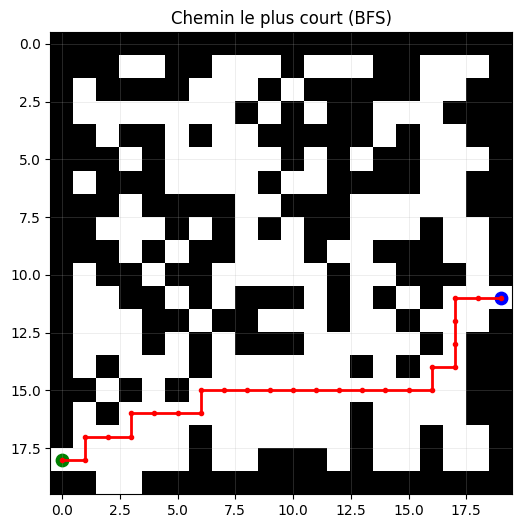

In [48]:
# -------------------------
# Chemin "optimal" (BFS)
# -------------------------
length, path, list_dist = chemin_de_sortie_A_star(grid)

# Convert path -> array
path = np.array(path)

# Plot grid
plt.figure(figsize=(6, 6))
plt.imshow(grid, cmap="gray_r", origin="upper")

# Plot chemin en rouge
plt.plot(path[:, 1], path[:, 0], color="red", linewidth=2, marker="o", markersize=3)

# Start / End
plt.scatter(path[0, 1], path[0, 0], color="green", s=80)
plt.scatter(path[-1, 1], path[-1, 0], color="blue", s=80)

plt.grid(True, linewidth=0.5, alpha=0.3)
plt.title("Chemin le plus court (BFS)")
plt.show()